In [54]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_classification

In [67]:
import pandas as pd

# Desbalanceamento de dados

In [57]:
x1 = np.random.randn(10000,2) + 1.3
x2 = np.random.randn(500,2)

y1 = np.ones(10000)
y2 = np.zeros(500)

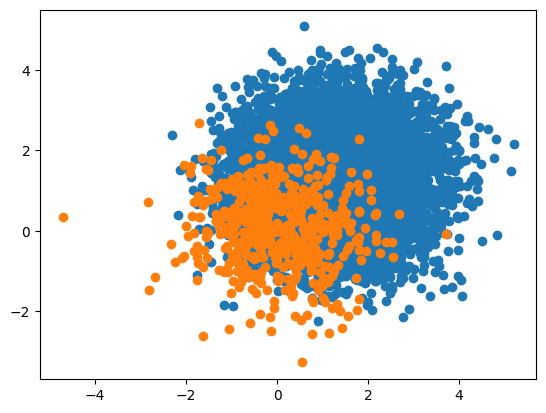

In [58]:
plt.scatter(x1[:,0], x1[:,1])
plt.scatter(x2[:,0], x2[:,1])

In [59]:
x = np.vstack([x1, x2])
y = np.concat([y1, y2])

In [60]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [61]:
pipeline_steps = [
    ('scaler', StandardScaler()),
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42))
]

pipeline = Pipeline(steps=pipeline_steps)

pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('random_forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [62]:
y_pred = pipeline.predict(X_test)

In [63]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy}")

Test accuracy: 0.9547619047619048


In [64]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy}")

Test accuracy: 0.9547619047619048


In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.48      0.27      0.35        89
         1.0       0.97      0.99      0.98      2011

    accuracy                           0.96      2100
   macro avg       0.72      0.63      0.66      2100
weighted avg       0.95      0.96      0.95      2100



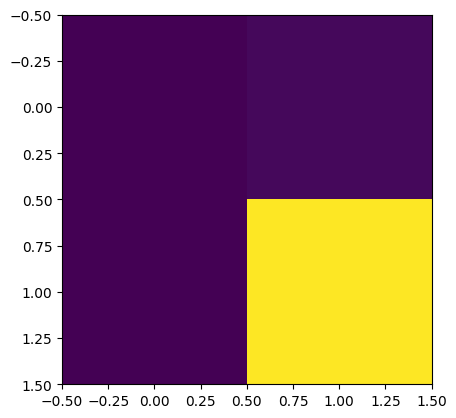

In [52]:
plt.imshow(confusion_matrix(y_test, y_pred))

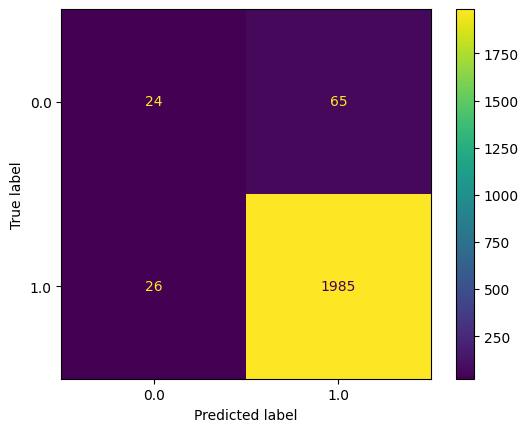

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=pipeline.classes_
)

plt.savefig("images/confusion-matrix.png")

In [75]:
with open('data/x_train.npy', 'wb') as f:
    np.save(f, X_train)

with open('data/y_train.npy', 'wb') as f:
    np.save(f, y_train)

with open('data/x_test.npy', 'wb') as f:
    np.save(f, X_test)

with open('data/y_test.npy', 'wb') as f:
    np.save(f, y_test)


In [82]:
zero_indices = np.where(y_test == 0)[0]
one_indices = np.where(y_test == 1)[0]

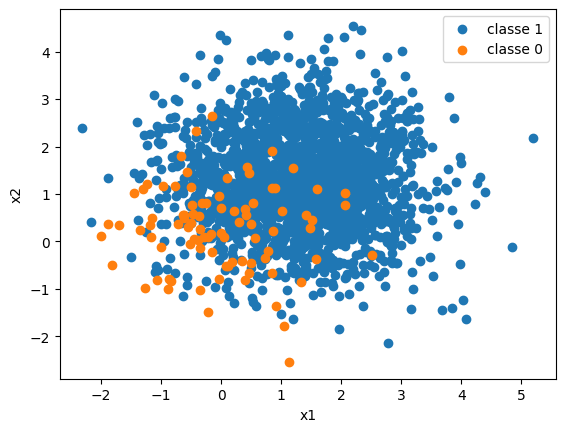

In [93]:
plt.scatter(X_test[one_indices,0], X_test[one_indices,1], label="classe 1")
plt.scatter(X_test[zero_indices,0], X_test[zero_indices,1], label="classe 0")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()

plt.savefig("images/viz-data.png")